In [4]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
import optuna
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

recall=  TP / (TP + FN)
precision = TP / (TP + FP)

In [5]:
with open('../../data/enhanced_trades_df_v2.pkl', 'rb') as f:
    trades = pickle.load(f)

In [6]:
# trades["random_feature"] = np.random.randn(len(trades))

In [7]:
trades=trades.sort_values(by="entry_date")

In [8]:
trades

,Symbol,entry_date,entry_price,exit_date,exit_price,return,Close,stock_ret_1d,Index_Close,index_ret_1d,...,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,Industry,kmeans_cluster,hmm_cluster,Industry_woe
1866,CHOLAFIN,2016-02-15,134.476151,2016-02-18,124.656219,-7.302359,134.476151,-0.002078,7162.950195,0.026071,...,0.000247,-0.497161,16.879064,1.789091,-0.182210,0,Financial Services,1.0,3.0,-0.045808
5829,NMDC,2016-03-09,13.149165,2016-04-28,13.738341,4.480711,13.149165,-0.015344,7531.799805,0.006212,...,0.000438,-0.943376,13.231202,1.863594,0.137517,1,Metals & Mining,1.0,3.0,0.122240
4604,KAJARIACER,2016-03-09,433.838593,2016-03-10,427.726288,-1.408889,433.838593,-0.011439,7531.799805,0.006212,...,0.000209,-0.515929,17.622795,0.897134,-0.159584,0,Consumer Durables,1.0,3.0,0.151036
8027,UNOMINDA,2016-03-15,29.365425,2016-06-24,37.435398,27.481207,29.365425,-0.016564,7460.600098,-0.010366,...,0.000819,-0.308800,4.868548,0.924446,-0.073163,1,Automobile and Auto Components,1.0,3.0,0.153940
5155,MANAPPURAM,2016-03-18,29.691771,2016-04-04,29.069004,-2.097438,29.691771,0.019746,7604.350098,0.012220,...,0.000462,0.345390,44.170453,1.784400,0.084666,0,Financial Services,2.0,3.0,-0.045808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4631,KAJARIACER,2025-09-01,1221.827637,2025-09-02,1205.879395,-1.305278,1221.827637,0.013393,24625.050781,0.008114,...,0.000249,-0.136997,19.234284,0.211822,0.032594,0,Consumer Durables,4.0,2.0,0.151036
2334,DELHIVERY,2025-09-01,473.750000,2025-09-03,478.000000,0.897098,473.750000,0.012178,24625.050781,0.008114,...,0.000079,-0.051993,45.248206,1.369613,0.318466,1,Services,4.0,2.0,-0.107717
2216,DALBHARAT,2025-09-03,2411.600098,2025-09-11,2409.800049,-0.074641,2411.600098,0.003913,24715.050781,0.005511,...,0.000040,-0.512479,86.756612,0.975810,-0.043655,0,Construction Materials,4.0,2.0,-0.203289
1288,BIKAJI,2025-09-05,800.049988,2025-09-08,786.049988,-1.749891,800.049988,-0.001622,24741.000000,0.000271,...,0.000092,0.323486,82.790995,0.826002,0.015868,0,Fast Moving Consumer Goods,0.0,2.0,-0.049471


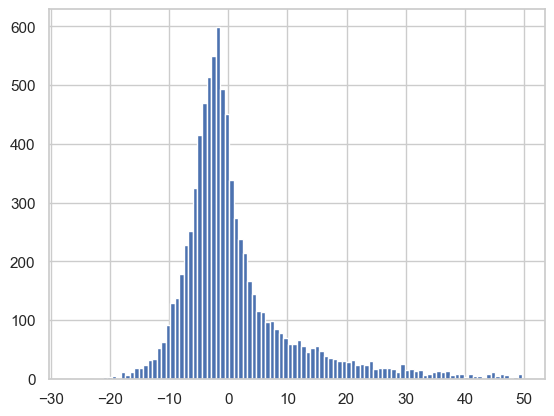

In [9]:
trades[(trades["return"]<50) & (trades["return"]>-40)]["return"].hist(bins=100);

In [10]:
trades["result"] = np.where(trades["return"] < 1, 1, 0)

In [11]:
print(trades["result"].value_counts())

result
1    5500
0    2961
Name: count, dtype: int64


In [12]:
trades.columns

Index(['Symbol', 'entry_date', 'entry_price', 'exit_date', 'exit_price',
       'return', 'Close', 'stock_ret_1d', 'Index_Close', 'index_ret_1d',
       'index_ret_5d', 'index_ret_20d', 'index_vol', 'index_vol_5d',
       'index_vol_20d', 'plus_di', 'minus_di', 'adx', 'rsi', 'roc_5', 'roc_14',
       'roc_30', 'atr_5', 'atr_14', 'atr_30', 'vol_5d', 'vol_14d', 'vol_30d',
       '5_days_high', '14_days_high', '30_days_high', 'macd', 'macd_signal',
       'macd_hist', 'rel_ret', 'beta', 'corr', 'stock_vol', 'excess_vol',
       'parkinson_vol', 'gk_vol', 'vol_of_vol', 'skew', 'kurt', 'dsv', 'vol_z',
       'vol_vol_ratio', 'obv_z', 'vwap_dev', 'result', 'Industry',
       'kmeans_cluster', 'hmm_cluster', 'Industry_woe'],
      dtype='object')

In [13]:
to_drop = ["Symbol", "entry_price", "exit_date","exit_price","Close","return" ,"Industry", "Index_Close", 'entry_date']

In [14]:
df= trades.drop(columns=to_drop)

In [15]:
df

,stock_ret_1d,index_ret_1d,index_ret_5d,index_ret_20d,index_vol,index_vol_5d,index_vol_20d,plus_di,minus_di,adx,...,kurt,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,kmeans_cluster,hmm_cluster,Industry_woe
1866,-0.002078,0.026071,-0.030363,-0.036953,0.014520,0.021656,0.014520,28.081653,9.693355,30.567291,...,-1.327180,0.000247,-0.497161,16.879064,1.789091,-0.182210,1,1.0,3.0,-0.045808
5829,-0.015344,0.006212,0.042853,0.032008,0.015809,0.008721,0.015809,42.862165,12.001263,33.866604,...,5.825553,0.000438,-0.943376,13.231202,1.863594,0.137517,0,1.0,3.0,0.122240
4604,-0.011439,0.006212,0.042853,0.032008,0.015809,0.008721,0.015809,20.729521,13.779476,30.839855,...,2.625161,0.000209,-0.515929,17.622795,0.897134,-0.159584,1,1.0,3.0,0.151036
8027,-0.016564,-0.010366,-0.003300,0.041554,0.012519,0.007168,0.012519,28.031426,13.160294,30.139046,...,5.836611,0.000819,-0.308800,4.868548,0.924446,-0.073163,0,1.0,3.0,0.153940
5155,0.019746,0.012220,0.012536,0.057371,0.011733,0.008200,0.011733,29.159315,8.280356,31.274674,...,-1.093851,0.000462,0.345390,44.170453,1.784400,0.084666,1,2.0,3.0,-0.045808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4631,0.013393,0.008114,-0.009853,-0.005786,0.006531,0.007893,0.006531,20.338567,19.228822,31.600503,...,3.497779,0.000249,-0.136997,19.234284,0.211822,0.032594,1,4.0,2.0,0.151036
2334,0.012178,0.008114,-0.009853,-0.005786,0.006531,0.007893,0.006531,23.411484,21.574339,32.593471,...,9.894245,0.000079,-0.051993,45.248206,1.369613,0.318466,1,4.0,2.0,-0.107717
2216,0.003913,0.005511,0.000121,-0.000311,0.006230,0.006741,0.006230,29.762190,13.528196,30.525300,...,1.131378,0.000040,-0.512479,86.756612,0.975810,-0.043655,1,4.0,2.0,-0.203289
1288,-0.001622,0.000271,0.012861,0.006788,0.006145,0.004104,0.006145,31.877920,14.167454,30.426162,...,3.854778,0.000092,0.323486,82.790995,0.826002,0.015868,1,0.0,2.0,-0.049471


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8461 entries, 1866 to 8218
Data columns (total 45 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   stock_ret_1d    8461 non-null   float32
 1   index_ret_1d    8461 non-null   float64
 2   index_ret_5d    8461 non-null   float64
 3   index_ret_20d   8461 non-null   float64
 4   index_vol       8461 non-null   float64
 5   index_vol_5d    8461 non-null   float64
 6   index_vol_20d   8461 non-null   float64
 7   plus_di         8461 non-null   float64
 8   minus_di        8461 non-null   float64
 9   adx             8461 non-null   float64
 10  rsi             8461 non-null   float64
 11  roc_5           8461 non-null   float64
 12  roc_14          8461 non-null   float64
 13  roc_30          8461 non-null   float64
 14  atr_5           8461 non-null   float64
 15  atr_14          8461 non-null   float64
 16  atr_30          8461 non-null   float64
 17  vol_5d          8461 non-null   flo

In [17]:
df.columns

Index(['stock_ret_1d', 'index_ret_1d', 'index_ret_5d', 'index_ret_20d',
       'index_vol', 'index_vol_5d', 'index_vol_20d', 'plus_di', 'minus_di',
       'adx', 'rsi', 'roc_5', 'roc_14', 'roc_30', 'atr_5', 'atr_14', 'atr_30',
       'vol_5d', 'vol_14d', 'vol_30d', '5_days_high', '14_days_high',
       '30_days_high', 'macd', 'macd_signal', 'macd_hist', 'rel_ret', 'beta',
       'corr', 'stock_vol', 'excess_vol', 'parkinson_vol', 'gk_vol',
       'vol_of_vol', 'skew', 'kurt', 'dsv', 'vol_z', 'vol_vol_ratio', 'obv_z',
       'vwap_dev', 'result', 'kmeans_cluster', 'hmm_cluster', 'Industry_woe'],
      dtype='object')

In [18]:
cols = ['adx','rsi','roc_14', 'roc_30',
    'index_ret_5d', 'index_ret_20d', 'index_vol_5d', 'index_vol_20d','kmeans_cluster','hmm_cluster', 
    'result' ]

In [19]:
df = df[cols]

In [20]:
# X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["result"]), df["result"], test_size=0.2, random_state=42, stratify=df["result"])

# get first 80% of rows as training set and last 20% as test set
train_size = int(0.8 * len(df))
X_train = df.drop(columns=["result"]).iloc[:train_size]
X_test = df.drop(columns=["result"]).iloc[train_size:]
y_train = df["result"].iloc[:train_size]
y_test = df["result"].iloc[train_size:]

In [21]:
X_train

,adx,rsi,roc_14,roc_30,index_ret_5d,index_ret_20d,index_vol_5d,index_vol_20d,kmeans_cluster,hmm_cluster
1866,30.567291,65.594342,15.606248,9.407445,-0.030363,-0.036953,0.021656,0.014520,1.0,3.0
5829,33.866604,75.574806,20.197326,33.014426,0.042853,0.032008,0.008721,0.015809,1.0,3.0
4604,30.839855,56.039001,4.384034,-3.946686,0.042853,0.032008,0.008721,0.015809,1.0,3.0
8027,30.139046,57.928487,18.843343,11.903453,-0.003300,0.041554,0.007168,0.012519,1.0,3.0
5155,31.274674,69.605429,17.370177,29.607879,0.012536,0.057371,0.008200,0.011733,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...
1572,31.301799,73.664509,26.523387,19.895611,0.017350,0.003086,0.005231,0.007148,0.0,2.0
6439,30.318325,67.200212,13.887480,1.044183,0.017350,0.003086,0.005231,0.007148,0.0,2.0
6052,32.343711,77.703764,24.169266,34.922420,0.017350,0.003086,0.005231,0.007148,0.0,2.0
5763,30.145219,78.066345,20.410578,12.934136,0.017350,0.003086,0.005231,0.007148,0.0,2.0


In [22]:
one_hot_cols = ["kmeans_cluster", "hmm_cluster"]
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_ohe = ohe.fit_transform(X_train[one_hot_cols])
test_ohe = ohe.transform(X_test[one_hot_cols])

train_ohe_df = pd.DataFrame(train_ohe, columns=ohe.get_feature_names_out(one_hot_cols), index=X_train.index)
test_ohe_df = pd.DataFrame(test_ohe, columns=ohe.get_feature_names_out(one_hot_cols), index=X_test.index)

X_train_ohe = pd.concat([X_train.drop(columns=one_hot_cols), train_ohe_df], axis=1)
X_test_ohe = pd.concat([X_test.drop(columns=one_hot_cols), test_ohe_df], axis=1)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_ohe)
X_test_scaled = sc.transform(X_test_ohe)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_ohe.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_ohe.columns, index=X_test.index)

In [23]:
X_train_scaled

,adx,rsi,roc_14,roc_30,index_ret_5d,index_ret_20d,index_vol_5d,index_vol_20d,kmeans_cluster_0.0,kmeans_cluster_1.0,kmeans_cluster_2.0,kmeans_cluster_3.0,kmeans_cluster_4.0,hmm_cluster_0.0,hmm_cluster_1.0,hmm_cluster_2.0,hmm_cluster_3.0,hmm_cluster_4.0
1866,-0.455480,-0.265832,0.352247,-0.616227,-2.188832,-1.949509,3.294735,1.718864,-0.802195,3.126831,-0.830341,-0.059655,-0.340727,-0.735039,-0.55687,-0.646970,2.803326,-0.067834
5829,0.472343,0.917775,0.781933,1.374515,1.946485,0.032121,0.327245,2.057090,-0.802195,3.126831,-0.830341,-0.059655,-0.340727,-0.735039,-0.55687,-0.646970,2.803326,-0.067834
4604,-0.378831,-1.399022,-0.698057,-1.742361,1.946485,0.032121,0.327245,2.057090,-0.802195,3.126831,-0.830341,-0.059655,-0.340727,-0.735039,-0.55687,-0.646970,2.803326,-0.067834
8027,-0.575910,-1.174943,0.655212,-0.405742,-0.660276,0.306438,-0.029151,1.193368,-0.802195,3.126831,-0.830341,-0.059655,-0.340727,-0.735039,-0.55687,-0.646970,2.803326,-0.067834
5155,-0.256552,0.209853,0.517336,1.087246,0.234154,0.760955,0.207691,0.987131,-0.802195,-0.319813,1.204325,-0.059655,-0.340727,-0.735039,-0.55687,-0.646970,2.803326,-0.067834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1572,-0.248924,0.691229,1.373999,0.268225,0.506012,-0.798970,-0.473602,-0.216486,1.246580,-0.319813,-0.830341,-0.059655,-0.340727,-0.735039,-0.55687,1.545666,-0.356719,-0.067834
6439,-0.525494,-0.075388,0.191385,-1.321489,0.506012,-0.798970,-0.473602,-0.216486,1.246580,-0.319813,-0.830341,-0.059655,-0.340727,-0.735039,-0.55687,1.545666,-0.356719,-0.067834
6052,0.044079,1.170254,1.153673,1.535413,0.506012,-0.798970,-0.473602,-0.216486,1.246580,-0.319813,-0.830341,-0.059655,-0.340727,-0.735039,-0.55687,1.545666,-0.356719,-0.067834
5763,-0.574174,1.213253,0.801892,-0.318826,0.506012,-0.798970,-0.473602,-0.216486,1.246580,-0.319813,-0.830341,-0.059655,-0.340727,-0.735039,-0.55687,1.545666,-0.356719,-0.067834


In [24]:
# pca = PCA(n_components=30, random_state=42)
# X_train_pca=pca.fit_transform(X_train_scaled)
# X_test_pca=pca.transform(X_test_scaled)
# X_train_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])], index=X_train.index)
# X_test_pca = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])], index=X_test.index)
# # df_pca['result'] = y_train

In [25]:
# X_train_pca

In [26]:
# calculate class weights
class_weights = y_train.value_counts(normalize=True)
class_weights = {cls: 1/weight for cls, weight in class_weights.items()}
class_weights

{1: 1.5558620689655174, 0: 2.7990074441687347}

In [24]:
# class_weights = {0: 1, 1: 2}

In [76]:
X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape

((6768, 18), (1693, 18), (6768,), (1693,))

In [26]:
def y_train_shuffle(random_state=42):
    return y_train.sample(frac=1, random_state=random_state).reset_index(drop=True).copy()

In [27]:
for c in [0.001, 0.01, 0.1, 1, 10, 100]:
    print(f"Class weight: {c}")
    lg = LogisticRegression(class_weight=class_weights, C=c, max_iter=1000, random_state=42, n_jobs=-1)
    lg.fit(X_train_scaled, y_train)
    predictions = lg.predict(X_test_scaled)
    print(classification_report(y_test, predictions))

Class weight: 0.001


              precision    recall  f1-score   support

           0       0.37      0.81      0.51       265
           1       0.67      0.22      0.34       469

    accuracy                           0.43       734
   macro avg       0.52      0.52      0.42       734
weighted avg       0.56      0.43      0.40       734

Class weight: 0.01
              precision    recall  f1-score   support

           0       0.37      0.75      0.50       265
           1       0.67      0.28      0.40       469

    accuracy                           0.45       734
   macro avg       0.52      0.52      0.45       734
weighted avg       0.56      0.45      0.44       734

Class weight: 0.1
              precision    recall  f1-score   support

           0       0.37      0.74      0.50       265
           1       0.67      0.30      0.41       469

    accuracy                           0.46       734
   macro avg       0.52      0.52      0.46       734
weighted avg       0.57      0.46    

In [33]:
predictions = lg.predict(X_test_scaled)

In [46]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.63      0.54      0.58       433
           1       0.45      0.54      0.49       301

    accuracy                           0.54       734
   macro avg       0.54      0.54      0.53       734
weighted avg       0.55      0.54      0.54       734



<Axes: title={'center': 'Feature Importance'}>

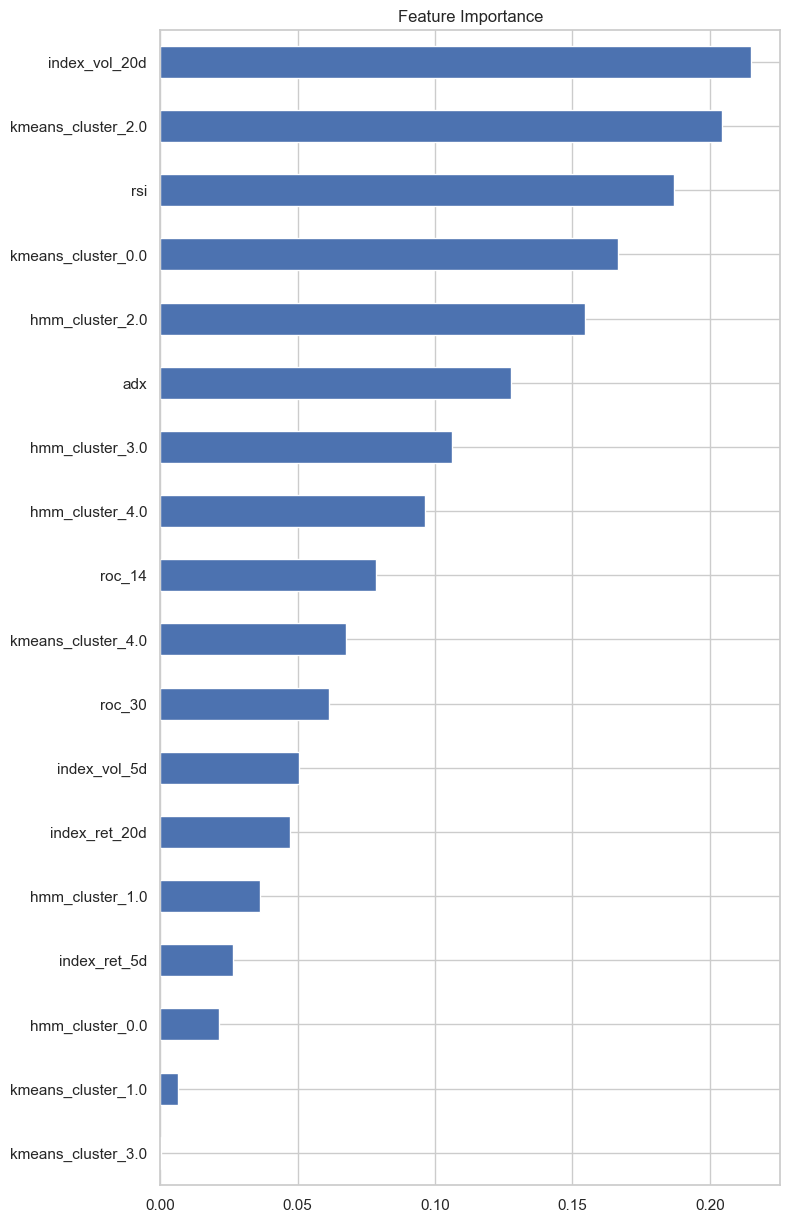

In [28]:
# plot feature importance
plt.figure(figsize=(8,15))
importance = pd.Series(lg.coef_[0], index=X_train_scaled.columns)
# make values absolute
importance = importance.abs()
importance = importance.sort_values()
importance.plot(kind='barh', title='Feature Importance')

In [77]:
rf = RandomForestClassifier(class_weight=class_weights, n_estimators=100, random_state=42, n_jobs=-1, max_depth=3)
rf.fit(X_train_scaled, y_train)
predictions_rf = rf.predict(X_test_scaled)
print("Random Forest Classifier")
print(classification_report(y_test, predictions_rf))

Random Forest Classifier
              precision    recall  f1-score   support

           0       0.37      0.68      0.48       543
           1       0.75      0.45      0.57      1150

    accuracy                           0.53      1693
   macro avg       0.56      0.57      0.52      1693
weighted avg       0.63      0.53      0.54      1693



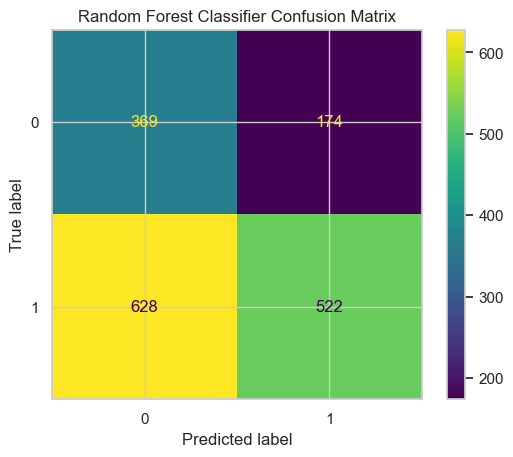

In [78]:
# confusion matrix
cm = confusion_matrix(y_test, predictions_rf, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot()
plt.title("Random Forest Classifier Confusion Matrix")
plt.show()

In [31]:
# Get prediction probabilities
y_proba = rf.predict_proba(X_test_scaled)[:, 1]  # probability of profit (class 1)

# Try different thresholds
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred_thresh))
    
    # Calculate profit recall specifically
    profit_recall = recall_score(y_test, y_pred_thresh, pos_label=1)
    print(f"Loss Recall: {profit_recall:.3f}")


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       265
           1       0.64      1.00      0.78       469

    accuracy                           0.64       734
   macro avg       0.32      0.50      0.39       734
weighted avg       0.41      0.64      0.50       734

Loss Recall: 1.000

Threshold: 0.35
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       265
           1       0.64      1.00      0.78       469

    accuracy                           0.64       734
   macro avg       0.82      0.51      0.40       734
weighted avg       0.77      0.64      0.51       734

Loss Recall: 1.000

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.47      0.17      0.25       265
           1       0.66      0.90      0.76       469

    accuracy                           0.63       734
   macro avg       0.56      0.53      0.

/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.12/sit

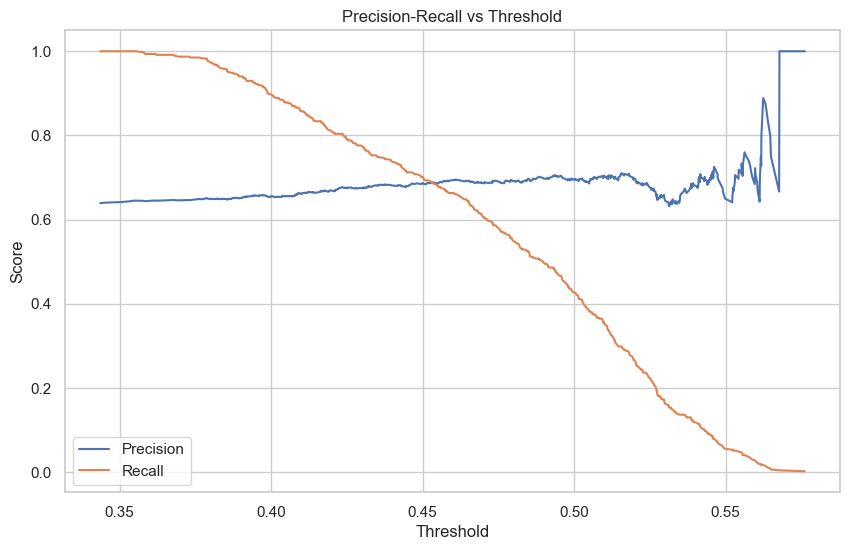

In [32]:
from sklearn.metrics import precision_recall_curve

# Plot precision-recall curve to find optimal threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall') 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

n_estimators: 279
    learning_rate: 0.07102467817012613
    max_depth: 30
    num_leaves: 168

In [53]:
lgb = LGBMClassifier(class_weight=class_weights, n_estimators=279, n_jobs=-1, max_depth=30, num_leaves=168, learning_rate=0.0710)
# shuffle y_train
lgb.fit(X_train_scaled, y_train)
predictions_lgb = lgb.predict(X_test_scaled)
print("LightGBM Classifier")
print(classification_report(y_test, predictions_lgb))

[LightGBM] [Info] Number of positive: 1917, number of negative: 1018
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000773 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2064
[LightGBM] [Info] Number of data points in the train set: 2935, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

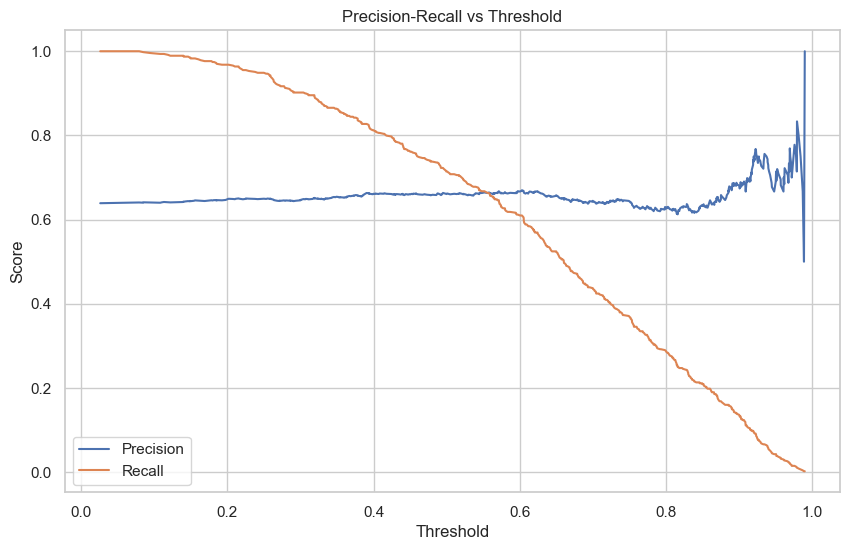

In [34]:
y_proba = lgb.predict_proba(X_test_scaled)[:, 1]  # probability of profit (class 1)
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall') 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

In [ ]:
# set up optuna for LightGBM
def objective_lgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 32),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'class_weight': class_weights,
        'random_state': 42,
        'n_jobs': -1,

    }
    
    model = LGBMClassifier(**param)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    f1 = f1_score(y_test, preds)
    return f1
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=30)
print("Best trial:")
trial = study_lgb.best_trial
print(f"  F1 Score: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")    

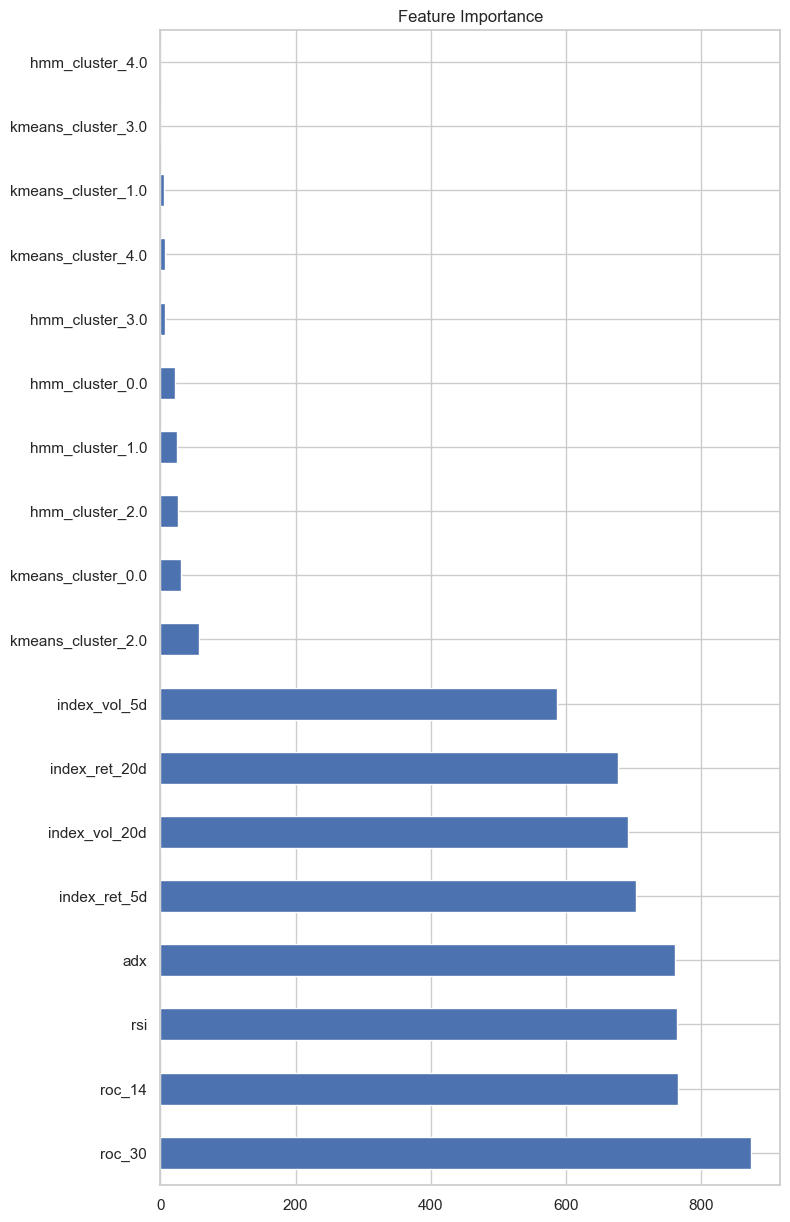

In [35]:
# plot feature importance
plt.figure(figsize=(8,15))
importance = pd.Series(lgb.feature_importances_, index=X_train_scaled.columns)
importance = importance.sort_values(ascending=False)
importance.plot(kind='barh', title='Feature Importance')
plt.show()

In [36]:
class_weights[0]/class_weights[1]

0.37213651238896683

 Params: 
    scale_pos_weight: 2.56995875232523
    threshold: 0.5632695939400867
    n_estimators: 151
    max_depth: 4
    learning_rate: 0.10795029249990817

In [34]:
xgb = XGBClassifier(scale_pos_weight=class_weights[1]/class_weights[0], n_estimators=151, learning_rate=0.10795029249990817, random_state=42, n_jobs=-1, max_depth=4,  eval_metric= 'logloss')
# shuffle y_train
# y_train = y_train.sample(frac=1, random_state=42).reset_index(drop=True)
xgb.fit(X_train_scaled, y_train)
predictions_xgb = xgb.predict(X_test_scaled)
print("XGBoost Classifier")
print(classification_report(y_test, predictions_xgb))

XGBoost Classifier
              precision    recall  f1-score   support

           0       0.34      0.53      0.42       543
           1       0.70      0.52      0.60      1150

    accuracy                           0.52      1693
   macro avg       0.52      0.53      0.51      1693
weighted avg       0.59      0.52      0.54      1693



In [35]:
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]  # probability of profit (class 1)

In [36]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores_thr = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores_thr)
# best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_threshold = 0.5632695939400867
# Apply threshold
y_pred = (y_proba >= best_threshold).astype(int)

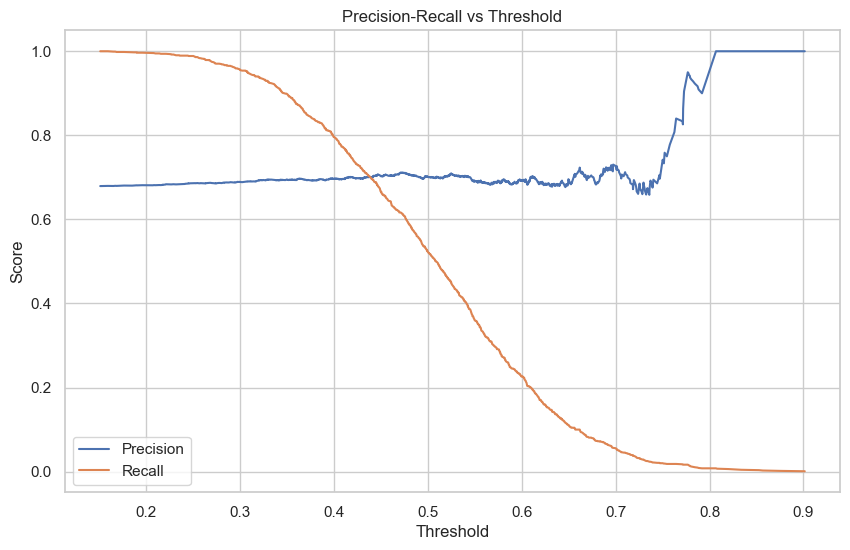

In [38]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall') 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.32      0.69      0.44       543
           1       0.69      0.32      0.44      1150

    accuracy                           0.44      1693
   macro avg       0.50      0.50      0.44      1693
weighted avg       0.57      0.44      0.44      1693



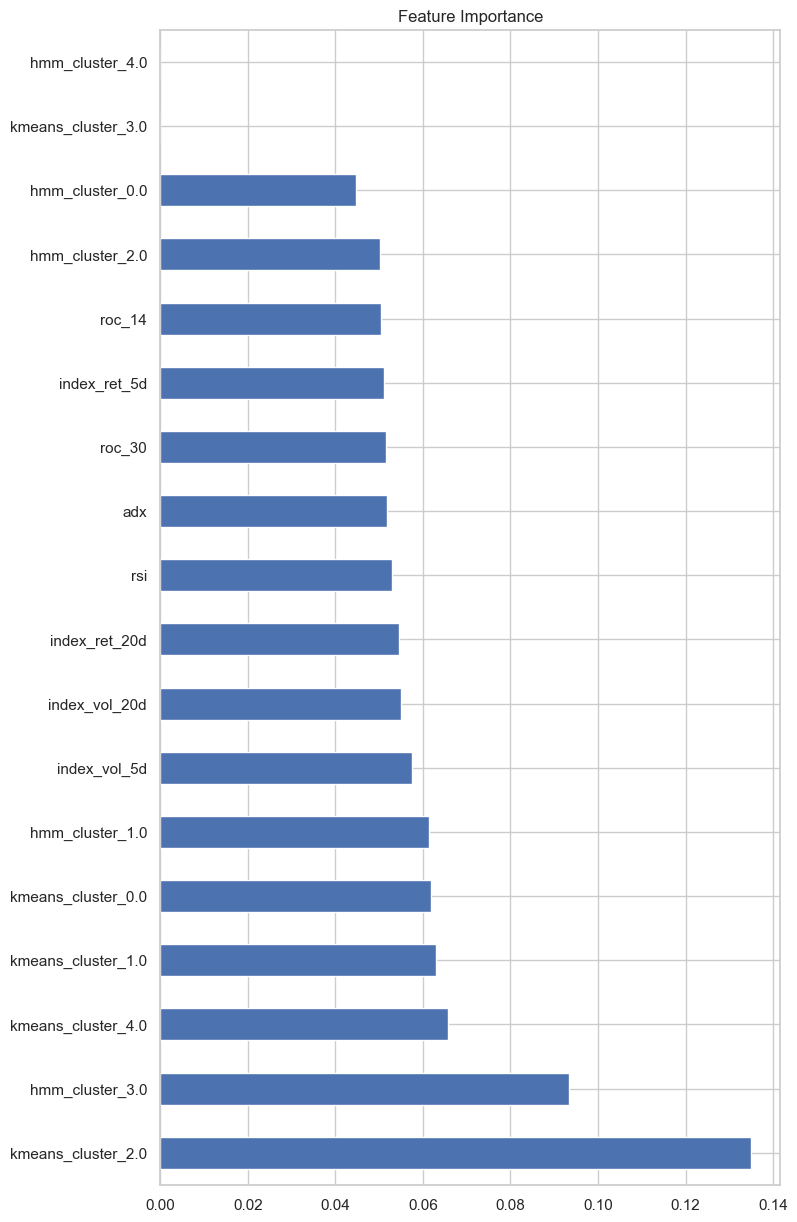

In [43]:
# plot feature importance
plt.figure(figsize=(8,15))
importance = pd.Series(xgb.feature_importances_, index=X_train_scaled.columns)
importance = importance.sort_values(ascending=False)
importance.plot(kind='barh', title='Feature Importance')
plt.show()

In [23]:
y_train.value_counts(), y_test.value_counts()

(result
 1    1909
 0    1026
 Name: count, dtype: int64,
 result
 1    477
 0    257
 Name: count, dtype: int64)

In [24]:
1909/1026, 1026/1909

(1.8606237816764133, 0.5374541644840231)

In [28]:
class_weights[0]/class_weights[1]

1.860623781676413

In [ ]:
# optuna hyperparameter tuning for xgboost
def objective(trial):
    param = {
        'scale_pos_weight': class_weights[0]/class_weights[1],
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        # 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        # 'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    
    xgb = XGBClassifier(**param)
    xgb.fit(X_train_scaled, y_train)
    preds = xgb.predict(X_test_scaled)
    f1 = f1_score(y_test, preds)
    
    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300)
print("Best trial:")
trial = study.best_trial
print(f"  F1 Score: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")    

[I 2025-10-05 09:46:50,376] A new study created in memory with name: no-name-dc1f1f24-0385-4390-b5f4-2a4e2e8d5b8f
[I 2025-10-05 09:46:51,061] Trial 0 finished with value: 0.6792452830188679 and parameters: {'scale_pos_weight': 0.53, 'n_estimators': 212, 'max_depth': 10}. Best is trial 0 with value: 0.6792452830188679.
[I 2025-10-05 09:46:51,400] Trial 1 finished with value: 0.7543186180422264 and parameters: {'scale_pos_weight': 1.86, 'n_estimators': 55, 'max_depth': 19}. Best is trial 1 with value: 0.7543186180422264.
[I 2025-10-05 09:46:51,900] Trial 2 finished with value: 0.7519230769230769 and parameters: {'scale_pos_weight': 1.86, 'n_estimators': 169, 'max_depth': 9}. Best is trial 1 with value: 0.7543186180422264.
[I 2025-10-05 09:46:52,665] Trial 3 finished with value: 0.6783754116355654 and parameters: {'scale_pos_weight': 0.53, 'n_estimators': 298, 'max_depth': 8}. Best is trial 1 with value: 0.7543186180422264.
[I 2025-10-05 09:46:52,737] Trial 4 finished with value: 0.792452

Best trial:
  F1 Score: 0.7982683982683982
  Params: 
    scale_pos_weight: 1.86
    n_estimators: 54
    max_depth: 4


In [113]:
class_weights[1] / class_weights[0]

0.5374541644840231

In [114]:
class_weights

{1: 1.5374541644840232, 0: 2.8606237816764133}

In [ ]:


def objective(trial):
    scale_pos_weight = class_weights[1] / class_weights[0]

    # Hyperparameters to tune
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        # 'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        # 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }

    xgb = XGBClassifier(**param)
        
    xgb.fit(X_train_scaled, y_train)
    
    y_proba = xgb.predict_proba(X_test_scaled)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores_thr = 2 * (precision * recall) / (precision + recall + 1e-9)
    best_idx = np.argmax(f1_scores_thr)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

    y_pred = (y_proba >= best_threshold).astype(int)

    f1 = f1_score(y_test, y_pred, pos_label=1)
        # f1_scores.append(f1)

    return f1


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300)
print("Best trial:")
trial = study.best_trial
print(f"  F1 Score: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")    


[I 2025-10-06 00:40:30,686] A new study created in memory with name: no-name-bed9a8ae-b9a0-4aaa-b6b5-fc660218deed
[I 2025-10-06 00:40:31,465] Trial 0 finished with value: 0.8093056045118082 and parameters: {'n_estimators': 197, 'max_depth': 11, 'learning_rate': 0.196516364250166}. Best is trial 0 with value: 0.8093056045118082.
[I 2025-10-06 00:40:32,660] Trial 1 finished with value: 0.809004572634541 and parameters: {'n_estimators': 195, 'max_depth': 20, 'learning_rate': 0.27215079878238047}. Best is trial 0 with value: 0.8093056045118082.
[I 2025-10-06 00:40:32,936] Trial 2 finished with value: 0.809004572634541 and parameters: {'n_estimators': 111, 'max_depth': 7, 'learning_rate': 0.15939239229830918}. Best is trial 0 with value: 0.8093056045118082.
[I 2025-10-06 00:40:34,349] Trial 3 finished with value: 0.809004572634541 and parameters: {'n_estimators': 260, 'max_depth': 17, 'learning_rate': 0.1867147621557883}. Best is trial 0 with value: 0.8093056045118082.
[I 2025-10-06 00:40:3

Best trial:
  F1 Score: 0.8119022316684378
  Params: 
    n_estimators: 65
    max_depth: 3
    learning_rate: 0.022931909731849283


In [33]:
def objective_business(trial):
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 0.3, 2.0)
    threshold = trial.suggest_float('threshold', 0.3, 0.8)
    
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }
    
    xgb = XGBClassifier(**param)
    xgb.fit(X_train_scaled, y_train)
    
    y_proba = xgb.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    # Get confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Business logic: 
    # - Each missed profit costs us potential gain
    # - Each missed loss costs us actual money
    # - Each false alarm costs us missed opportunity
    
    profit_captured = tn  # True negatives = correctly identified profits
    profits_missed = fn   # False negatives = missed profits  
    losses_caught = tp    # True positives = caught losses
    losses_missed = fp    # False positives = missed losses (predicted profit but was loss)
    
    # Custom business score
    business_score = (
        profit_captured * 1.0 +      # Each profit captured
        losses_caught * 2.0 -        # Each loss avoided (higher weight)
        profits_missed * 0.5 -       # Each profit missed (opportunity cost)
        losses_missed * 3.0          # Each loss taken (actual cost)
    )
    
    return business_score

def objective_balanced_v2(trial):
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 0.5, 3.0)
    threshold = trial.suggest_float('threshold', 0.4, 0.7)
    
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }
    
    xgb = XGBClassifier(**param)
    xgb.fit(X_train_scaled, y_train)
    
    y_proba = xgb.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    class_0_recall = recall_score(y_test, y_pred, pos_label=0)
    class_1_recall = recall_score(y_test, y_pred, pos_label=1) 
    class_1_precision = precision_score(y_test, y_pred, pos_label=1)
    
    # Rebalanced weights - prioritize loss detection more
    weighted_score = (
        0.25 * class_0_recall +      # Reduced weight for profit capture
        0.50 * class_1_recall +      # Higher priority on catching losses
        0.25 * class_1_precision     # Maintain some precision
    )
    
    return weighted_score

study = optuna.create_study(direction="maximize")
study.optimize(objective_balanced_v2, n_trials=300)
print("Best trial:")
trial = study.best_trial
print(f"  F1 Score: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")    

[I 2025-10-06 15:58:20,743] A new study created in memory with name: no-name-f4fd2a25-ff94-4b25-a0e3-b69a0916acc5
[I 2025-10-06 15:58:21,916] Trial 0 finished with value: 0.5444485335774727 and parameters: {'scale_pos_weight': 0.9038191388089949, 'threshold': 0.6519739358932682, 'n_estimators': 144, 'max_depth': 18, 'learning_rate': 0.011654970628045047}. Best is trial 0 with value: 0.5444485335774727.
[I 2025-10-06 15:58:22,688] Trial 1 finished with value: 0.6696525869235516 and parameters: {'scale_pos_weight': 1.9027072004819252, 'threshold': 0.4700522008845471, 'n_estimators': 128, 'max_depth': 13, 'learning_rate': 0.01668230918803544}. Best is trial 1 with value: 0.6696525869235516.
[I 2025-10-06 15:58:23,777] Trial 2 finished with value: 0.5435498846614448 and parameters: {'scale_pos_weight': 0.657738184430643, 'threshold': 0.6627732480555576, 'n_estimators': 232, 'max_depth': 11, 'learning_rate': 0.0492006280825666}. Best is trial 1 with value: 0.6696525869235516.
[I 2025-10-06 

Best trial:
  F1 Score: 0.6809327636891893
  Params: 
    scale_pos_weight: 2.56995875232523
    threshold: 0.5632695939400867
    n_estimators: 151
    max_depth: 4
    learning_rate: 0.10795029249990817
